## Compare Model1/Model1S with plain DOY input and sin-cos DOY input

Both encoding schemes have been trained on ResOps reservoirs, with all other configurations held constant.

In [1]:
import os
print(f"Current Directory: {os.getcwd()}")
os.chdir("..")
print(f"New Directory: {os.getcwd()}")

Current Directory: c:\Users\mattc\Documents\DL-reservoir-modeling\additional_experiments
New Directory: c:\Users\mattc\Documents\DL-reservoir-modeling


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.basemap import Basemap
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from math import floor
import os
import copy
from scipy import stats
from scipy.stats import theilslopes
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
import seaborn as sns
import re

from src.data.data_processing import *
from src.data.data_fetching import *
from src.models.model_zoo import *
from src.models.predict_model import *
from src.models.train_model import *
from src.models.hyperparameter_tuning import *
from src.models.analyze_lstm_cell import *

In [3]:
model1_r2 = pd.read_csv('report/results/resops_training/resops_individual_r2.csv', index_col=0)
model1s_r2 = pd.read_csv('report/results/resops_training/resops_benchmark_lstm_w_storage_r2.csv', index_col=0)
model1_r2_sincos = pd.read_csv('report/results/additional_experiments/resops_training_sincos/resops_individual_r2_sincos.csv', index_col=0)
model1s_r2_sincos = pd.read_csv('report/results/additional_experiments/resops_training_sincos/resops_individual_storage_r2_sincos.csv', index_col=0)

# Convert to long format
model1_r2 = model1_r2.melt(value_vars=['train', 'val', 'test'])
model1s_r2 = model1s_r2.melt(value_vars=['train', 'val', 'test'])
model1_r2_sincos = model1_r2_sincos.melt(value_vars=['train', 'val', 'test'])
model1s_r2_sincos = model1s_r2_sincos.melt(value_vars=['train', 'val', 'test'])

# Add model type
model1_r2['DOY Encoding'] = 'integer'
model1s_r2['DOY Encoding'] = 'integer'
model1_r2_sincos['DOY Encoding'] = 'sin-cos'
model1s_r2_sincos['DOY Encoding'] = 'sin-cos'

# Concat
model1_r2_all = pd.concat([model1_r2, model1_r2_sincos], axis=0)
model1s_r2_all = pd.concat([model1s_r2, model1s_r2_sincos], axis=0)

In [4]:
model1_r2_all.groupby(['DOY Encoding', 'variable'])['value'].median()

DOY Encoding  variable
integer       test        0.566793
              train       0.645785
              val         0.618378
sin-cos       test        0.590024
              train       0.700614
              val         0.640072
Name: value, dtype: float64

In [5]:
model1s_r2_all.groupby(['DOY Encoding', 'variable'])['value'].median()

DOY Encoding  variable
integer       test        0.658247
              train       0.775444
              val         0.712742
sin-cos       test        0.677153
              train       0.797870
              val         0.728252
Name: value, dtype: float64

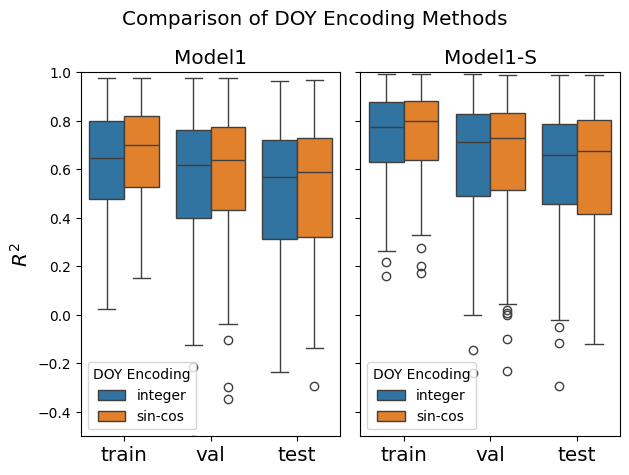

In [6]:
# Plot distribution of performance
fig, axes = plt.subplots(ncols=2, sharey=True)
bp1 = sns.boxplot(data=model1_r2_all, x='variable', y='value', hue='DOY Encoding', ax=axes[0])
axes[0].set_title('Model1', size='x-large')
axes[0].set_ylabel('$R^2$', size='x-large')
axes[0].set_xlabel('')
bp2 = sns.boxplot(data=model1s_r2_all, x='variable', y='value', hue='DOY Encoding', ax=axes[1])
axes[1].set_title('Model1-S', size='x-large')
axes[1].set_ylabel('$R^2$', size='x-large')
axes[1].set_xlabel('')

plt.setp(axes[0].get_xticklabels(), size='x-large')
plt.setp(axes[1].get_xticklabels(), size='x-large')

fig.suptitle('Comparison of DOY Encoding Methods', size='x-large')
plt.ylim(-0.5, 1)
plt.tight_layout()
plt.savefig('report/results/additional_experiments/resops_training_sincos/compare_doy_encoding.png', dpi=300)
plt.show()